In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# shells.tif is in a1images
IMG_DIR  = os.path.normpath(os.path.join(os.getcwd(), '..', 'question', 'a1images'))
SAVE_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

# pad the kernel into a 256x256 grid, take the 2D FFT, then shift zero-freq to centre
# log magnitude later so the low-energy parts are still visible
def freq_response_2d(kernel, size=256):
    pad = np.zeros((size, size))
    kh, kw = kernel.shape
    pad[:kh, :kw] = kernel
    H = np.fft.fftshift(np.abs(np.fft.fft2(pad)))
    return H

In [2]:
# build the three kernels to compare in frequency domain
# box: flat 15x15 kernel, all equal weights
# gauss: built manually with sigma=4 over a 51x51 grid, then normalised
# lap: standard 4-connected laplacian for edge detection
N = 256

box = np.ones((15, 15), dtype=np.float64) / 225.0

ax = np.arange(-25, 26, dtype=np.float64)
X, Y = np.meshgrid(ax, ax)
g = np.exp(-(X**2 + Y**2) / (2 * 4**2))
gauss_k = g / g.sum()

lap = np.array([[0,  1, 0],
                [1, -4, 1],
                [0,  1, 0]], dtype=np.float64)

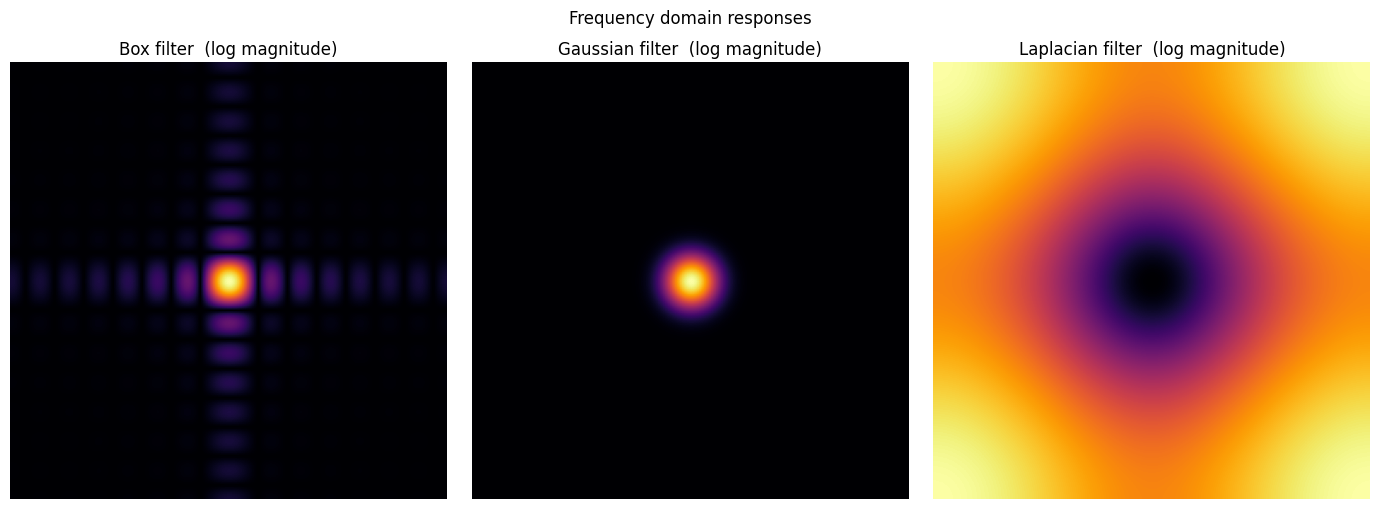

In [3]:
# get the freq response for each, then plot with log scale
# box should show ringing sidelobes; gauss is smooth; lap peaks at high freq
H_box   = freq_response_2d(box, N)
H_gauss = freq_response_2d(gauss_k, N)

lap_pad = np.zeros((N, N))
lap_pad[:3, :3] = lap
H_lap = np.fft.fftshift(np.abs(np.fft.fft2(lap_pad)))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax_plot, H, t in zip(axes,
                         [H_box, H_gauss, H_lap],
                         ['Box filter', 'Gaussian filter', 'Laplacian filter']):
    ax_plot.imshow(np.log1p(H), cmap='inferno')
    ax_plot.set_title(t + '  (log magnitude)')
    ax_plot.axis('off')

plt.suptitle('Frequency domain responses', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q11_freq_response.png'), dpi=150)
plt.show()

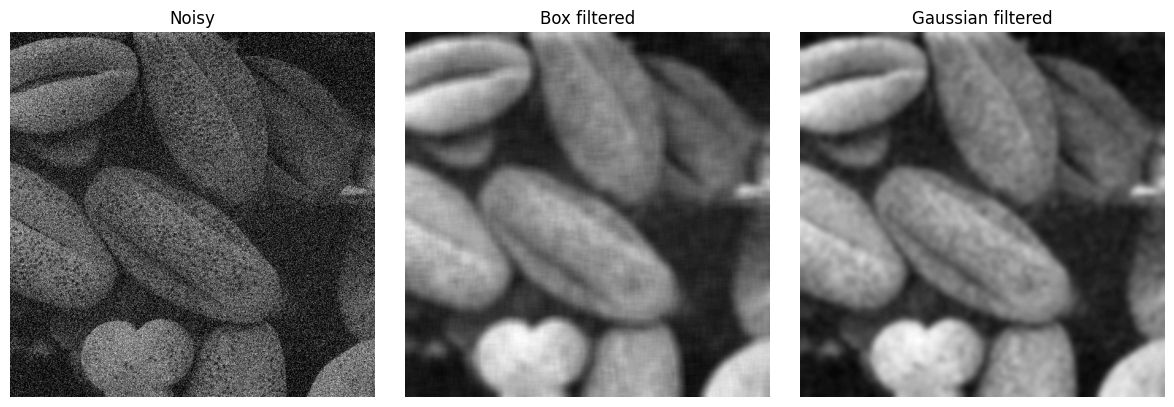

In [4]:
# add gaussian noise to shells.tif (seed=0 so its reproducible)
# then apply box and gaussian filters and compare — gaussian should look cleaner
img = cv2.imread(os.path.join(IMG_DIR, 'shells.tif'), cv2.IMREAD_GRAYSCALE)
np.random.seed(0)
noise = (np.random.randn(*img.shape) * 20).astype(np.int16)
noisy = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

box_out   = cv2.blur(noisy, (15, 15))
gauss_out = cv2.GaussianBlur(noisy, (0, 0), 4)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax_plot, im, t in zip(axes,
                           [noisy, box_out, gauss_out],
                           ['Noisy', 'Box filtered', 'Gaussian filtered']):
    ax_plot.imshow(im, cmap='gray')
    ax_plot.set_title(t)
    ax_plot.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'q11_filtering_comparison.png'), dpi=150)
plt.show()